In [2]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
from FinMind.data import DataLoader
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] 
# plt.rcParams['font.sans-serif'] = ['Arial Unicode Ms']

api = DataLoader()

In [2]:
# 取得全台灣ETF商品標的
stock_info = api.taiwan_stock_info()
ETF_group = stock_info[stock_info["industry_category"] == "ETF"]

2025-12-04 19:08:11.434 | INFO     | FinMind.data.finmind_api:get_data:158 - download Dataset.TaiwanStockInfo, data_id: 


In [3]:
ETF_group

,industry_category,stock_id,stock_name,type,date
446,ETF,00732,國泰RMB短期報酬,twse,2024-12-04
448,ETF,00729R,第一金工業30反1,twse,2024-12-04
450,ETF,00906,大華元宇宙科技50,twse,2024-12-04
462,ETF,00742,新光內需收益,twse,2024-12-04
464,ETF,00743,國泰中國A150,twse,2024-12-04
...,...,...,...,...,...
3077,ETF,00982D,主動富邦動態入息,twse,2025-12-04
3078,ETF,00983A,主動中信ARK創新,twse,2025-12-04
3080,ETF,00983D,主動富邦複合收益,twse,2025-12-04
3081,ETF,00984A,主動安聯台灣高息,twse,2025-12-04


In [4]:
symbols = ETF_group[(ETF_group["stock_name"].str.contains("元大"))&(ETF_group["stock_id"].astype(str).str.len()==4)].iloc[1:]

In [5]:
symbols

,industry_category,stock_id,stock_name,type,date
1369,ETF,0050,元大台灣50,twse,2025-12-04
2780,ETF,0051,元大中型100,twse,2025-12-04
2782,ETF,0053,元大電子,twse,2025-12-04
2783,ETF,0055,元大MSCI金融,twse,2025-12-04
2784,ETF,0056,元大高股息,twse,2025-12-04
2786,ETF,0061,元大寶滬深,twse,2025-12-04


In [8]:
all_datas = []
for index,row in symbols.iterrows():
    data = yf.download(row['stock_id'] + ".TW" , start = '2005-01-01')
    data.columns = data.columns.set_levels([row['stock_name']],level=1)
    all_datas.append(data)
all_data = pd.concat(all_datas,axis=1)

C:\Users\USER\AppData\Local\Temp\ipykernel_26988\898500158.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(row['stock_id'] + ".TW" , start = '2005-01-01')
[*********************100%***********************]  1 of 1 completed
C:\Users\USER\AppData\Local\Temp\ipykernel_26988\898500158.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(row['stock_id'] + ".TW" , start = '2005-01-01')
[*********************100%***********************]  1 of 1 completed
C:\Users\USER\AppData\Local\Temp\ipykernel_26988\898500158.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(row['stock_id'] + ".TW" , start = '2005-01-01')
[*********************100%***********************]  1 of 1 completed
C:\Users\USER\AppData\Local\Temp\ipykernel_26988\898500158.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.do

In [9]:
all_data

Price,Close,High,Low,Open,Volume,Close,High,Low,Open,Volume,...,Close,High,Low,Open,Volume,Close,High,Low,Open,Volume
Ticker,元大台灣50,元大台灣50,元大台灣50,元大台灣50,元大台灣50,元大中型100,元大中型100,元大中型100,元大中型100,元大中型100,...,元大高股息,元大高股息,元大高股息,元大高股息,元大高股息,元大寶滬深,元大寶滬深,元大寶滬深,元大寶滬深,元大寶滬深
Date,,,,,,,,,,,,,,,,,,,,,
2008-01-02,NaN,NaN,NaN,NaN,NaN,21.974087,21.974087,21.974087,21.974087,0,...,11.544789,11.544789,11.544789,11.544789,0,NaN,NaN,NaN,NaN,NaN
2008-01-03,NaN,NaN,NaN,NaN,NaN,21.582874,21.582874,21.582874,21.582874,0,...,11.333662,11.333662,11.333662,11.333662,0,NaN,NaN,NaN,NaN,NaN
2008-01-04,NaN,NaN,NaN,NaN,NaN,21.702227,21.702227,21.702227,21.702227,0,...,11.459440,11.459440,11.459440,11.459440,0,NaN,NaN,NaN,NaN,NaN
2008-01-07,NaN,NaN,NaN,NaN,NaN,20.720884,20.720884,20.720884,20.720884,0,...,11.162959,11.162959,11.162959,11.162959,0,NaN,NaN,NaN,NaN,NaN
2008-01-08,NaN,NaN,NaN,NaN,NaN,20.813715,20.813715,20.813715,20.813715,0,...,11.401039,11.401039,11.401039,11.401039,0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-28,62.349998,62.400002,61.849998,61.950001,66700125.0,90.500000,90.500000,89.099998,89.099998,70303,...,36.020000,36.130001,35.930000,36.060001,26127469,22.209999,22.360001,22.200001,22.360001,587207.0
2025-12-01,61.500000,61.950001,61.400002,61.799999,96548521.0,89.500000,90.550003,89.300003,90.550003,127125,...,36.000000,36.119999,35.950001,36.000000,23375577,22.420000,22.469999,22.250000,22.280001,579000.0


In [11]:
all_data['Close'].pct_change().corr()

C:\Users\USER\AppData\Local\Temp\ipykernel_26988\277822871.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  all_data['Close'].pct_change().corr()


Ticker,元大台灣50,元大中型100,元大電子,元大MSCI金融,元大高股息,元大寶滬深
Ticker,,,,,,
元大台灣50,1.000000,0.451449,0.572442,0.461427,0.508648,0.275625
元大中型100,0.451449,1.000000,0.729799,0.696699,0.787056,0.346095
元大電子,0.572442,0.729799,1.000000,0.636967,0.757905,0.346119
元大MSCI金融,0.461427,0.696699,0.636967,1.000000,0.729402,0.382704
元大高股息,0.508648,0.787056,0.757905,0.729402,1.000000,0.353333
元大寶滬深,0.275625,0.346095,0.346119,0.382704,0.353333,1.000000


C:\Users\USER\AppData\Local\Temp\ipykernel_26988\2663130060.py:2: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  corr = round(all_data['Close'].pct_change().corr(), 3)


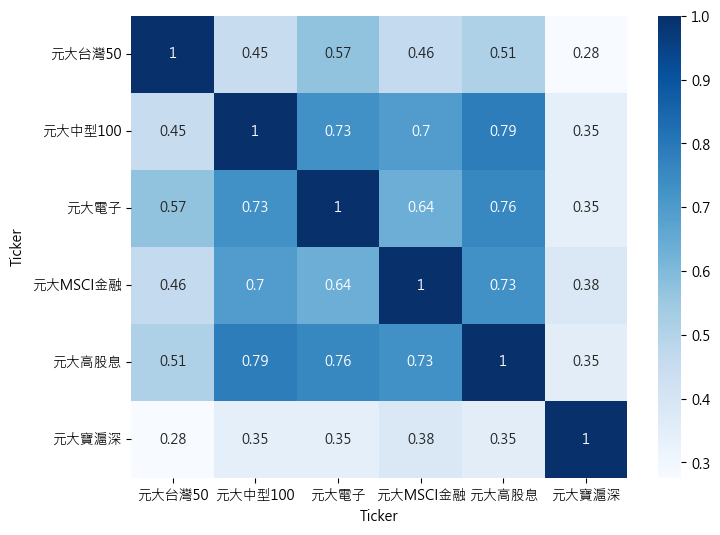

In [13]:
# 計算相關性
corr = round(all_data['Close'].pct_change().corr(), 3)

# 並繪製熱力圖
plt.figure(figsize=(8, 6))
sns.heatmap(corr, cmap="Blues", annot=True)
plt.show()

In [ ]:
import requests
# 取得全世界指數商品標的
url = "https://finance.yahoo.com/world-indices"
header = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/131.0.0.0 Safari/537.36'}
html = requests.get(url, headers=header)
web_data = pd.read_html(html.text)[0]

all_datas = []
for index,row in web_data.iterrows():
    data = yf.download(row['Symbol'])
    data.columns = data.columns.set_levels([row['Name']], level=1)
    if data.shape[0] < 1000:
        continue
    all_datas.append(data)
all_data = pd.concat(all_datas,axis=1)

# 計算相關性
corr = round(all_data['Adj Close'].pct_change().corr(), 3)

# 並繪製熱力圖
plt.figure(figsize=(18, 14))
sns.heatmap(corr, cmap="Blues", annot=True)
plt.show()